<a href="https://colab.research.google.com/github/Vishal-WD/AquaSense/blob/main/Grammar_Rule_Miner_Email_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

!apt-get update -qq
!apt-get install -y -qq tesseract-ocr

!pip install -q --upgrade \
    pymupdf \
    pytesseract \
    pillow \
    langchain \
    langchain-core \
    langchain-text-splitters \
    langchain-google-genai \
    pydantic \
    pandas \
    reportlab \
    rapidfuzz \
    google-api-python-client \
    google-auth \
    google-auth-oauthlib \
    google-auth-httplib2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [38]:
# ============================================================
# 2. IMPORTS
# ============================================================

import os
import re
import json
import uuid
import base64
import mimetypes
import unicodedata

import imaplib
import smtplib
import email

from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
from typing import Literal
from email.message import EmailMessage
from email.header import decode_header
from email.utils import parseaddr
from xml.sax.saxutils import escape

import fitz
import pandas as pd
import pytesseract

from PIL import Image
from rapidfuzz import fuzz
from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib import colors
from reportlab.lib.units import mm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    KeepTogether
)

from google.colab import drive, userdata, files

print("✅ Imports completed")

✅ Imports completed


In [2]:
# ============================================================
# 3. GOOGLE DRIVE STORAGE
# ============================================================

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent"
)

INCOMING_DIR = PROJECT_DIR / "incoming_pdfs"
OUTPUT_DIR = PROJECT_DIR / "output_pdfs"
DATA_DIR = PROJECT_DIR / "data"
LOG_DIR = PROJECT_DIR / "logs"
AUTH_DIR = PROJECT_DIR / "auth"

for folder in [
    PROJECT_DIR,
    INCOMING_DIR,
    OUTPUT_DIR,
    DATA_DIR,
    LOG_DIR,
    AUTH_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

RULES_CSV = DATA_DIR / "grammar_rules.csv"
RULES_JSON = DATA_DIR / "grammar_rules.json"
HISTORY_CSV = LOG_DIR / "processing_history.csv"
PROCESSED_EMAILS_JSON = LOG_DIR / "processed_emails.json"

CREDENTIALS_PATH = AUTH_DIR / "credentials.json"
TOKEN_PATH = AUTH_DIR / "gmail_token.pickle"

print("✅ Project folders created")
print("Project:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Project folders created
Project: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent


In [3]:
# ============================================================
# 4. INITIALIZE STORAGE
# ============================================================

RULE_COLUMNS = [
    "rule_id",
    "source_pdf",
    "page_number",
    "error_sentence",
    "correct_sentence",
    "grammar_rule",
    "source_type",
    "confidence_score",
    "created_at"
]

HISTORY_COLUMNS = [
    "source_pdf",
    "pages_processed",
    "ocr_pages",
    "items_detected",
    "valid_corrections",
    "new_rules",
    "duplicates_skipped",
    "rejected_items",
    "failed_chunks",
    "status",
    "processed_at"
]

if not RULES_CSV.exists():
    pd.DataFrame(
        columns=RULE_COLUMNS
    ).to_csv(
        RULES_CSV,
        index=False,
        encoding="utf-8"
    )

if not RULES_JSON.exists():
    with open(
        RULES_JSON,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump([], file, indent=2)

if not HISTORY_CSV.exists():
    pd.DataFrame(
        columns=HISTORY_COLUMNS
    ).to_csv(
        HISTORY_CSV,
        index=False,
        encoding="utf-8"
    )

if not PROCESSED_EMAILS_JSON.exists():
    with open(
        PROCESSED_EMAILS_JSON,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump([], file, indent=2)

print("✅ Storage initialized")
print("Stored rules:", len(pd.read_csv(RULES_CSV)))

✅ Storage initialized
Stored rules: 0


In [4]:
# ============================================================
# 5. GEMINI SETUP
# ============================================================

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY is missing from Colab Secrets."
    )

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_retries=3
)

test_response = llm.invoke(
    "Reply only with: Gemini connected"
)

print(test_response.content)

Gemini connected


In [5]:
# ============================================================
# 6. STRUCTURED OUTPUT SCHEMA
# ============================================================

class GrammarCorrection(BaseModel):
    question_number: int | None = Field(
        default=None,
        description="Question number when available"
    )

    error_sentence: str = Field(
        description="Original grammatically incorrect sentence"
    )

    correct_sentence: str = Field(
        description="Corrected sentence preserving original meaning"
    )

    grammar_rule: str = Field(
        description="Concise rule explaining the correction"
    )

    source_type: Literal[
        "SOURCE_EXPLAINED",
        "ANSWER_DERIVED",
        "AI_INFERRED"
    ]

    confidence_score: float = Field(
        ge=0,
        le=1
    )

    source_page: int | None = None


class GrammarCorrectionBatch(BaseModel):
    corrections: list[GrammarCorrection]


structured_llm = llm.with_structured_output(
    GrammarCorrectionBatch,
    method="json_schema"
)

print("✅ Structured Gemini model ready")

✅ Structured Gemini model ready


In [6]:
# ============================================================
# 7. TEXT QUALITY CHECK
# ============================================================

def calculate_text_quality(text: str) -> dict:
    text = text.strip()

    if not text:
        return {
            "character_count": 0,
            "word_count": 0,
            "readable_ratio": 0.0,
            "alphabetic_ratio": 0.0,
            "quality_score": 0.0,
            "needs_ocr": True
        }

    total_characters = len(text)

    readable_characters = sum(
        character.isalnum()
        or character.isspace()
        or character in ".,;:!?'-()[]/"
        for character in text
    )

    alphabetic_characters = sum(
        character.isalpha()
        for character in text
    )

    words = re.findall(
        r"\b[A-Za-z]+\b",
        text
    )

    readable_ratio = (
        readable_characters / total_characters
    )

    alphabetic_ratio = (
        alphabetic_characters / total_characters
    )

    word_count = len(words)

    quality_score = (
        readable_ratio * 0.5
        + alphabetic_ratio * 0.3
        + min(word_count / 50, 1.0) * 0.2
    )

    needs_ocr = (
        total_characters < 80
        or word_count < 10
        or readable_ratio < 0.75
        or alphabetic_ratio < 0.35
        or quality_score < 0.60
    )

    return {
        "character_count": total_characters,
        "word_count": word_count,
        "readable_ratio": round(readable_ratio, 3),
        "alphabetic_ratio": round(alphabetic_ratio, 3),
        "quality_score": round(quality_score, 3),
        "needs_ocr": needs_ocr
    }


print("✅ Text-quality checker ready")

✅ Text-quality checker ready


In [7]:
# ============================================================
# 8. OCR FOR SCANNED PAGES
# ============================================================

def ocr_pdf_page(
    page: fitz.Page,
    dpi: int = 250
) -> str:

    zoom = dpi / 72
    matrix = fitz.Matrix(zoom, zoom)

    pixmap = page.get_pixmap(
        matrix=matrix,
        alpha=False
    )

    image = Image.frombytes(
        "RGB",
        [pixmap.width, pixmap.height],
        pixmap.samples
    )

    ocr_text = pytesseract.image_to_string(
        image,
        lang="eng",
        config="--oem 3 --psm 6"
    )

    return ocr_text.strip()


print("✅ OCR function ready")

✅ OCR function ready


In [8]:
# ============================================================
# 9. TEXT CLEANING
# ============================================================

def clean_pdf_text(text: str) -> str:
    if not text:
        return ""

    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Remove hidden control characters
    text = re.sub(
        r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]",
        "",
        text
    )

    # Join words broken using line-ending hyphens
    text = re.sub(
        r"(\w)-\s*\n\s*(\w)",
        r"\1\2",
        text
    )

    # Normalize punctuation
    replacements = {
        "–": "-",
        "—": "-",
        "“": '"',
        "”": '"',
        "‘": "'",
        "’": "'",
        "…": "..."
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # Remove explicit page labels only
    text = re.sub(
        r"(?im)^\s*page\s+\d+\s*$",
        "",
        text
    )

    # Normalize spaces
    text = re.sub(
        r"[ \t]+",
        " ",
        text
    )

    # Remove spaces before punctuation
    text = re.sub(
        r"\s+([,.;:!?])",
        r"\1",
        text
    )

    # Preserve numbered questions on separate lines
    text = re.sub(
        r"\s+(?=\d{1,4}[.)]\s+)",
        "\n",
        text
    )

    # Remove excessive blank lines
    text = re.sub(
        r"\n{3,}",
        "\n\n",
        text
    )

    cleaned_lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    return "\n".join(
        cleaned_lines
    ).strip()


def fix_sentence_line_breaks(text: str) -> str:
    if not text:
        return ""

    # Join line break before a four-digit year
    text = re.sub(
        r"([A-Za-z])\s*\n\s*(\d{4}[.,]?)",
        r"\1 \2",
        text
    )

    # Join a line when the next line starts lowercase
    text = re.sub(
        r"([A-Za-z,;:])\s*\n\s*([a-z])",
        r"\1 \2",
        text
    )

    return text.strip()


print("✅ Text-cleaning functions ready")

✅ Text-cleaning functions ready


In [9]:
# ============================================================
# 10. HEADER AND FOOTER CLEANING
# ============================================================

def find_repeated_headers_footers(
    page_texts: list[str],
    boundary_lines: int = 3,
    minimum_page_ratio: float = 0.5
) -> set[str]:

    line_counter = Counter()
    total_pages = len(page_texts)

    for text in page_texts:
        lines = [
            line.strip()
            for line in text.splitlines()
            if line.strip()
        ]

        boundary_candidates = (
            lines[:boundary_lines]
            + lines[-boundary_lines:]
        )

        unique_candidates = {
            line
            for line in boundary_candidates
            if 3 <= len(line) <= 150
        }

        line_counter.update(
            unique_candidates
        )

    minimum_occurrences = max(
        2,
        round(
            total_pages
            * minimum_page_ratio
        )
    )

    return {
        line
        for line, count in line_counter.items()
        if count >= minimum_occurrences
    }


def remove_headers_footers(
    text: str,
    repeated_lines: set[str],
    boundary_lines: int = 3
) -> str:

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    cleaned_lines = []

    for index, line in enumerate(lines):
        is_top = index < boundary_lines
        is_bottom = (
            index >= len(lines) - boundary_lines
        )

        if (
            line in repeated_lines
            and (is_top or is_bottom)
        ):
            continue

        cleaned_lines.append(line)

    return "\n".join(
        cleaned_lines
    ).strip()


print("✅ Header/footer cleaner ready")

✅ Header/footer cleaner ready


In [10]:
# ============================================================
# 11. UNIVERSAL PDF EXTRACTION
# ============================================================

def extract_and_clean_pdf(
    pdf_path: str | Path
) -> list[dict]:

    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(
            f"PDF not found: {pdf_path}"
        )

    preliminary_pages = []

    with fitz.open(pdf_path) as document:
        print(
            f"Total pages found: {len(document)}"
        )

        for page_index, page in enumerate(
            document
        ):
            page_number = page_index + 1

            extracted_text = (
                page.get_text("text").strip()
            )

            direct_quality = (
                calculate_text_quality(
                    extracted_text
                )
            )

            raw_text = extracted_text
            final_quality = direct_quality
            used_ocr = False
            extraction_method = "DIRECT"

            if direct_quality["needs_ocr"]:
                print(
                    f"Page {page_number}: "
                    "applying OCR"
                )

                ocr_text = ocr_pdf_page(page)

                ocr_quality = (
                    calculate_text_quality(
                        ocr_text
                    )
                )

                if (
                    ocr_quality["quality_score"]
                    > direct_quality["quality_score"]
                ):
                    raw_text = ocr_text
                    final_quality = ocr_quality
                    used_ocr = True
                    extraction_method = "OCR"

            cleaned_text = clean_pdf_text(
                raw_text
            )

            cleaned_text = (
                fix_sentence_line_breaks(
                    cleaned_text
                )
            )

            preliminary_pages.append({
                "page_number": page_number,
                "cleaned_text": cleaned_text,
                "used_ocr": used_ocr,
                "extraction_method":
                    extraction_method,
                "quality": final_quality
            })

    repeated_lines = (
        find_repeated_headers_footers(
            [
                page["cleaned_text"]
                for page in preliminary_pages
            ]
        )
    )

    final_pages = []

    for page in preliminary_pages:
        final_text = remove_headers_footers(
            page["cleaned_text"],
            repeated_lines
        )

        final_pages.append({
            "page_number":
                page["page_number"],
            "text":
                final_text,
            "used_ocr":
                page["used_ocr"],
            "extraction_method":
                page["extraction_method"],
            "quality_score":
                page["quality"]["quality_score"],
            "character_count":
                len(final_text)
        })

    readable_pages = sum(
        bool(page["text"].strip())
        for page in final_pages
    )

    ocr_pages = sum(
        page["used_ocr"]
        for page in final_pages
    )

    print()
    print("✅ Extraction completed")
    print("Readable pages:", readable_pages)
    print("OCR pages:", ocr_pages)
    print(
        "Repeated header/footer lines removed:",
        len(repeated_lines)
    )

    return final_pages

In [11]:
# ============================================================
# 12. MANUAL EXTRACTION TEST
# ============================================================

uploaded = files.upload()

if not uploaded:
    raise ValueError(
        "No file was uploaded."
    )

uploaded_name = next(iter(uploaded))

if not uploaded_name.lower().endswith(".pdf"):
    raise ValueError(
        "Upload a PDF file only."
    )

TEST_PDF_PATH = (
    INCOMING_DIR / uploaded_name
)

with open(
    TEST_PDF_PATH,
    "wb"
) as file:
    file.write(
        uploaded[uploaded_name]
    )

TEST_PAGES = extract_and_clean_pdf(
    TEST_PDF_PATH
)

print()
print("Saved PDF:", TEST_PDF_PATH)

Saving error_correction_practice.pdf to error_correction_practice (1).pdf
Total pages found: 7

✅ Extraction completed
Readable pages: 7
OCR pages: 0
Repeated header/footer lines removed: 0

Saved PDF: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent/incoming_pdfs/error_correction_practice (1).pdf


In [12]:
for page in TEST_PAGES[:5]:
    print("=" * 80)
    print("PAGE:", page["page_number"])
    print(
        "METHOD:",
        page["extraction_method"]
    )
    print(
        "QUALITY:",
        page["quality_score"]
    )
    print(
        "CHARACTERS:",
        page["character_count"]
    )
    print()
    print(page["text"][:1800])
    print()

PAGE: 1
METHOD: DIRECT
QUALITY: 0.929
CHARACTERS: 1264

Error Correction Practice Set
50 Sentences • TCS & CTS Placement Exam Pattern
Instructions: Each sentence below contains exactly one grammatical error. Identify the error and rewrite the sentence correctly.
Subject-Verb Agreement
1. Each of the students have submitted their assignment.
2. The number of applicants for the job are increasing every year.
3. Neither of the two candidates were selected for the interview.
4. The committee have decided to postpone the meeting.
5. A large number of employees was absent yesterday.
Tense Errors
6. She has completed her project before the deadline arrived.
7. By the time he reaches the station, the train had already left.
8. I have visited Paris last year during my vacation.
9. He is working in this company since 2015.
10. If I would have known earlier, I would have informed you.
Article Errors
11. He is the honest man in our office.
12. She bought an umbrella and a laptop yesterday.
13. Thi

In [13]:
# ============================================================
# 13. LANGCHAIN DOCUMENT PREPARATION
# ============================================================

def prepare_pdf_chunks(
    pages: list[dict],
    source_pdf_name: str,
    single_document_limit: int = 45000,
    chunk_size: int = 18000,
    chunk_overlap: int = 2500
) -> tuple[str, list[Document]]:

    readable_pages = [
        page
        for page in pages
        if page.get("text", "").strip()
    ]

    if not readable_pages:
        raise ValueError(
            "No readable pages are available."
        )

    combined_sections = []

    for page in readable_pages:
        combined_sections.append(
            f"\n--- PAGE {page['page_number']} ---\n"
            f"{page['text']}"
        )

    full_pdf_text = "\n".join(
        combined_sections
    )

    document = Document(
        page_content=full_pdf_text,
        metadata={
            "source_pdf": source_pdf_name,
            "total_pages": len(pages)
        }
    )

    if len(full_pdf_text) <= single_document_limit:
        chunks = [document]

        print(
            "✅ Small PDF: processing as one complete document"
        )

    else:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=[
                "\n--- PAGE ",
                "\nAnswer Key",
                "\nAnswers",
                "\nSolutions",
                "\nExplanation",
                "\n\n",
                "\n",
                ". ",
                " "
            ]
        )

        chunks = splitter.split_documents(
            [document]
        )

        print(
            f"✅ Large PDF split into {len(chunks)} chunks"
        )

    for index, chunk in enumerate(
        chunks,
        start=1
    ):
        chunk.metadata["chunk_id"] = index

        print(
            f"Chunk {index}: "
            f"{len(chunk.page_content)} characters"
        )

    return full_pdf_text, chunks


TEST_FULL_TEXT, TEST_CHUNKS = prepare_pdf_chunks(
    pages=TEST_PAGES,
    source_pdf_name=TEST_PDF_PATH.name
)

✅ Small PDF: processing as one complete document
Chunk 1: 9935 characters


In [14]:
# ============================================================
# 14. UNIVERSAL EXTRACTION PROMPT
# ============================================================

EXTRACTION_PROMPT = """
You are an English grammar error-correction extraction system.

Analyze the PDF content supplied below.

The PDF may contain any of the following:

- Incorrect sentences only
- Questions with answer keys
- Questions with answers and explanations
- Grammar theory with examples
- Mixed exercises and theory
- Multiple-choice questions
- Correct sentences used as distractors
- OCR-generated text with minor recognition errors

Extract only genuine English grammar corrections.

For every valid item return:

1. question_number
2. error_sentence
3. correct_sentence
4. grammar_rule
5. source_type
6. confidence_score
7. source_page

SOURCE TYPES:

SOURCE_EXPLAINED
Use when the PDF directly provides:
- the incorrect sentence,
- corrected sentence,
- and an explanation or rule.

ANSWER_DERIVED
Use when the PDF provides:
- the incorrect sentence,
- and corrected answer,
- but no clear rule explanation.

AI_INFERRED
Use when the PDF provides only the incorrect sentence.
Generate the correction and grammar rule carefully.

STRICT VALIDATION RULES:

- Extract only genuine grammatical errors.
- Preserve the original intended meaning.
- Do not rewrite sentences only for style.
- Do not treat spelling alone as a grammar correction.
- Do not treat punctuation alone as a grammar correction.
- Do not treat capitalization alone as a grammar correction.
- Do not include sentences marked "correct as is".
- Do not invent an error in an already correct sentence.
- Prefer the PDF's official answer key when available.
- Match questions and answers using question numbers.
- Return every correction only once.
- Do not return headings, instructions or unrelated theory.
- Ignore incomplete OCR fragments when the intended sentence
  cannot be determined confidently.
- Keep the grammar rule short, accurate and understandable.
- Use the page marker "--- PAGE N ---" to determine source_page.

CONFIDENCE GUIDANCE:

- 0.90 to 1.00:
  correction and rule are directly provided.

- 0.80 to 0.89:
  correction is provided but rule is inferred.

- 0.60 to 0.79:
  both correction and rule are AI inferred.

Return no item below 0.60 confidence.

PDF CONTENT:

{pdf_content}
"""

In [15]:
# ============================================================
# 15. RULE MINING
# ============================================================

def mine_grammar_corrections(
    chunks: list[Document]
) -> tuple[list[dict], list[dict]]:

    all_corrections = []
    failed_chunks = []

    total_chunks = len(chunks)

    for index, chunk in enumerate(
        chunks,
        start=1
    ):
        print(
            f"Processing chunk {index}/{total_chunks} "
            f"({len(chunk.page_content)} characters)"
        )

        prompt = EXTRACTION_PROMPT.format(
            pdf_content=chunk.page_content
        )

        try:
            result = structured_llm.invoke(
                prompt
            )

            chunk_corrections = []

            for correction in result.corrections:
                record = correction.model_dump()
                record["chunk_id"] = index

                chunk_corrections.append(
                    record
                )

            all_corrections.extend(
                chunk_corrections
            )

            print(
                f"✅ Chunk {index}: "
                f"{len(chunk_corrections)} corrections found"
            )

        except Exception as error:
            failed_chunks.append({
                "chunk_id": index,
                "error": str(error)
            })

            print(
                f"❌ Chunk {index} failed: {error}"
            )

    print()
    print(
        "✅ Total mined corrections:",
        len(all_corrections)
    )
    print(
        "Failed chunks:",
        len(failed_chunks)
    )

    return all_corrections, failed_chunks

In [16]:
TEST_MINED_CORRECTIONS, TEST_FAILED_CHUNKS = (
    mine_grammar_corrections(
        TEST_CHUNKS
    )
)

Processing chunk 1/1 (9935 characters)
✅ Chunk 1: 49 corrections found

✅ Total mined corrections: 49
Failed chunks: 0


In [17]:
# ============================================================
# 16. PREVIEW MINED RESULTS
# ============================================================

TEST_MINED_DF = pd.DataFrame(
    TEST_MINED_CORRECTIONS
)

preview_columns = [
    "question_number",
    "error_sentence",
    "correct_sentence",
    "grammar_rule",
    "source_type",
    "confidence_score",
    "source_page"
]

display(
    TEST_MINED_DF[
        preview_columns
    ].head(10)
)

print()
print("Source type counts:")

display(
    TEST_MINED_DF[
        "source_type"
    ].value_counts()
)

,question_number,error_sentence,correct_sentence,grammar_rule,source_type,confidence_score,source_page
0,1,Each of the students have submitted their assi...,Each of the students has submitted their assig...,'Each' takes a singular verb.,SOURCE_EXPLAINED,0.95,1
1,2,The number of applicants for the job are incre...,The number of applicants for the job is increa...,'The number of' takes a singular verb.,SOURCE_EXPLAINED,0.95,1
2,3,Neither of the two candidates were selected fo...,Neither of the two candidates was selected for...,'Neither' takes a singular verb.,SOURCE_EXPLAINED,0.95,1
3,4,The committee have decided to postpone the mee...,The committee has decided to postpone the meet...,Collective noun 'committee' takes singular verb.,SOURCE_EXPLAINED,0.95,1
4,5,A large number of employees was absent yesterday.,A large number of employees were absent yester...,'A number of' takes a plural verb.,SOURCE_EXPLAINED,0.95,1
5,6,She has completed her project before the deadl...,She had completed her project before the deadl...,Past perfect needed for the earlier action.,SOURCE_EXPLAINED,0.95,1
6,7,"By the time he reaches the station, the train ...","By the time he reaches the station, the train ...",Future perfect needed with 'by the time... rea...,SOURCE_EXPLAINED,0.95,1
7,8,I have visited Paris last year during my vacat...,I visited Paris last year during my vacation.,Simple past used with a specific past time ref...,SOURCE_EXPLAINED,0.95,1
8,9,He is working in this company since 2015.,He has been working in this company since 2015.,Present perfect continuous needed with 'since'.,SOURCE_EXPLAINED,0.95,1
9,10,"If I would have known earlier, I would have in...","If I had known earlier, I would have informed ...",Past perfect needed in the 'if' clause.,SOURCE_EXPLAINED,0.95,1



Source type counts:


source_type
SOURCE_EXPLAINED    49
Name: count, dtype: int64

In [18]:
# ============================================================
# 17. VALIDATE MINED RESULTS
# ============================================================

def normalize_text(value: str) -> str:
    value = str(value).lower().strip()
    value = re.sub(r"[^\w\s]", "", value)
    value = re.sub(r"\s+", " ", value)
    return value


def validate_mined_results(
    records: list[dict],
    minimum_confidence: float = 0.60
) -> tuple[list[dict], list[dict]]:

    valid_records = []
    rejected_records = []
    seen_pairs = set()

    for record in records:
        error_sentence = str(
            record.get("error_sentence", "")
        ).strip()

        correct_sentence = str(
            record.get("correct_sentence", "")
        ).strip()

        grammar_rule = str(
            record.get("grammar_rule", "")
        ).strip()

        confidence = float(
            record.get("confidence_score", 0)
        )

        rejection_reason = None

        if not error_sentence:
            rejection_reason = "Missing error sentence"

        elif not correct_sentence:
            rejection_reason = "Missing correct sentence"

        elif not grammar_rule:
            rejection_reason = "Missing grammar rule"

        elif confidence < minimum_confidence:
            rejection_reason = "Confidence below threshold"

        elif normalize_text(error_sentence) == normalize_text(
            correct_sentence
        ):
            rejection_reason = (
                "Error and correction are identical"
            )

        pair_key = (
            normalize_text(error_sentence),
            normalize_text(correct_sentence)
        )

        if (
            not rejection_reason
            and pair_key in seen_pairs
        ):
            rejection_reason = (
                "Duplicate within current PDF"
            )

        if rejection_reason:
            rejected_record = record.copy()
            rejected_record[
                "rejection_reason"
            ] = rejection_reason

            rejected_records.append(
                rejected_record
            )
            continue

        seen_pairs.add(pair_key)
        valid_records.append(record)

    return valid_records, rejected_records

In [19]:
TEST_VALID_CORRECTIONS, TEST_REJECTED_CORRECTIONS = (
    validate_mined_results(
        TEST_MINED_CORRECTIONS
    )
)

print(
    "✅ Valid corrections:",
    len(TEST_VALID_CORRECTIONS)
)

print(
    "Rejected corrections:",
    len(TEST_REJECTED_CORRECTIONS)
)

✅ Valid corrections: 49
Rejected corrections: 0


In [20]:
# ============================================================
# 18. LOAD EXISTING RULES
# ============================================================

def load_existing_rules() -> pd.DataFrame:
    if not RULES_CSV.exists():
        return pd.DataFrame(
            columns=RULE_COLUMNS
        )

    existing_df = pd.read_csv(
        RULES_CSV
    ).fillna("")

    return existing_df

In [21]:
# ============================================================
# 19. DUPLICATE DETECTION
# ============================================================

def separate_new_and_duplicate_rules(
    records: list[dict],
    existing_df: pd.DataFrame,
    similarity_threshold: int = 94
) -> tuple[list[dict], list[dict]]:

    new_records = []
    duplicate_records = []

    existing_pairs = []

    for _, row in existing_df.iterrows():
        existing_pairs.append({
            "error": normalize_text(
                row.get(
                    "error_sentence",
                    ""
                )
            ),
            "correct": normalize_text(
                row.get(
                    "correct_sentence",
                    ""
                )
            ),
            "rule": normalize_text(
                row.get(
                    "grammar_rule",
                    ""
                )
            )
        })

    for record in records:
        candidate_error = normalize_text(
            record["error_sentence"]
        )

        candidate_correct = normalize_text(
            record["correct_sentence"]
        )

        candidate_rule = normalize_text(
            record["grammar_rule"]
        )

        duplicate_found = False

        for existing in existing_pairs:
            error_score = fuzz.ratio(
                candidate_error,
                existing["error"]
            )

            correct_score = fuzz.ratio(
                candidate_correct,
                existing["correct"]
            )

            rule_score = fuzz.ratio(
                candidate_rule,
                existing["rule"]
            )

            if (
                error_score >= similarity_threshold
                and correct_score >= similarity_threshold
            ):
                duplicate_found = True
                break

            if (
                error_score >= 98
                and rule_score >= similarity_threshold
            ):
                duplicate_found = True
                break

        if duplicate_found:
            duplicate_records.append(
                record
            )
        else:
            new_records.append(
                record
            )

    return new_records, duplicate_records

In [22]:
TEST_EXISTING_RULES_DF = load_existing_rules()

(
    TEST_NEW_CORRECTIONS,
    TEST_DUPLICATE_CORRECTIONS
) = separate_new_and_duplicate_rules(
    TEST_VALID_CORRECTIONS,
    TEST_EXISTING_RULES_DF
)

print(
    "✅ New corrections:",
    len(TEST_NEW_CORRECTIONS)
)

print(
    "Duplicate corrections:",
    len(TEST_DUPLICATE_CORRECTIONS)
)

✅ New corrections: 49
Duplicate corrections: 0


In [23]:
# ============================================================
# 20. SAVE NEW RULES
# ============================================================

def save_new_corrections(
    records: list[dict],
    source_pdf: str
) -> pd.DataFrame:

    if not records:
        print("No new corrections to save.")

        return pd.DataFrame(
            columns=RULE_COLUMNS
        )

    existing_df = load_existing_rules()

    created_at = datetime.now(
        timezone.utc
    ).isoformat()

    rows_to_add = []

    for record in records:
        rows_to_add.append({
            "rule_id": str(uuid.uuid4()),
            "source_pdf": source_pdf,
            "page_number": record.get(
                "source_page",
                ""
            ),
            "error_sentence": record[
                "error_sentence"
            ].strip(),
            "correct_sentence": record[
                "correct_sentence"
            ].strip(),
            "grammar_rule": record[
                "grammar_rule"
            ].strip(),
            "source_type": record.get(
                "source_type",
                "AI_INFERRED"
            ),
            "confidence_score": record.get(
                "confidence_score",
                0
            ),
            "created_at": created_at
        })

    new_df = pd.DataFrame(
        rows_to_add,
        columns=RULE_COLUMNS
    )

    updated_df = pd.concat(
        [existing_df, new_df],
        ignore_index=True
    )

    updated_df.to_csv(
        RULES_CSV,
        index=False,
        encoding="utf-8"
    )

    json_records = updated_df.where(
        pd.notna(updated_df),
        None
    ).to_dict(
        orient="records"
    )

    with open(
        RULES_JSON,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            json_records,
            file,
            indent=2,
            ensure_ascii=False
        )

    print(
        "✅ New corrections saved:",
        len(new_df)
    )

    print(
        "✅ Total stored rules:",
        len(updated_df)
    )

    return new_df

In [24]:
TEST_SAVED_DF = save_new_corrections(
    TEST_NEW_CORRECTIONS,
    TEST_PDF_PATH.name
)

✅ New corrections saved: 49
✅ Total stored rules: 49


In [25]:
# ============================================================
# 21. OUTPUT PDF GENERATION
# ============================================================

def create_rules_pdf(
    records: list[dict],
    source_pdf_name: str,
    output_directory: Path
) -> Path:

    if not records:
        raise ValueError(
            "No valid corrections are available."
        )

    safe_name = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        Path(source_pdf_name).stem
    ).strip("_")

    output_path = (
        output_directory
        / f"{safe_name}_mined_corrections.pdf"
    )

    document = SimpleDocTemplate(
        str(output_path),
        pagesize=A4,
        rightMargin=18 * mm,
        leftMargin=18 * mm,
        topMargin=18 * mm,
        bottomMargin=18 * mm,
        title="Grammar Error Corrections",
        author="Grammar Rule Miner"
    )

    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        name="CorrectionTitle",
        parent=styles["Title"],
        fontName="Helvetica-Bold",
        fontSize=18,
        leading=22,
        alignment=TA_CENTER,
        spaceAfter=14
    )

    number_style = ParagraphStyle(
        name="CorrectionNumber",
        parent=styles["Heading3"],
        fontName="Helvetica-Bold",
        fontSize=12,
        leading=15,
        spaceBefore=6,
        spaceAfter=7
    )

    label_style = ParagraphStyle(
        name="CorrectionLabel",
        parent=styles["Normal"],
        fontName="Helvetica-Bold",
        fontSize=10.5,
        leading=14,
        spaceAfter=3
    )

    value_style = ParagraphStyle(
        name="CorrectionValue",
        parent=styles["Normal"],
        fontName="Helvetica",
        fontSize=10.5,
        leading=15,
        spaceAfter=8
    )

    separator_style = ParagraphStyle(
        name="CorrectionSeparator",
        parent=styles["Normal"],
        fontSize=8,
        leading=8,
        textColor=colors.grey,
        spaceBefore=2,
        spaceAfter=8
    )

    story = [
        Paragraph(
            "Grammar Error Corrections",
            title_style
        ),
        Spacer(1, 3 * mm)
    ]

    for index, record in enumerate(
        records,
        start=1
    ):
        error_sentence = escape(
            str(
                record["error_sentence"]
            ).strip()
        )

        correct_sentence = escape(
            str(
                record["correct_sentence"]
            ).strip()
        )

        grammar_rule = escape(
            str(
                record["grammar_rule"]
            ).strip()
        )

        correction_block = [
            Paragraph(
                f"Correction {index}",
                number_style
            ),
            Paragraph(
                "Error Sentence:",
                label_style
            ),
            Paragraph(
                error_sentence,
                value_style
            ),
            Paragraph(
                "Correct Sentence:",
                label_style
            ),
            Paragraph(
                correct_sentence,
                value_style
            ),
            Paragraph(
                "Rule:",
                label_style
            ),
            Paragraph(
                grammar_rule,
                value_style
            ),
            Paragraph(
                "_" * 90,
                separator_style
            )
        ]

        story.append(
            KeepTogether(
                correction_block
            )
        )

    document.build(story)

    print("✅ Output PDF generated")
    print("Path:", output_path)
    print("Corrections included:", len(records))

    return output_path

In [26]:
TEST_OUTPUT_PDF_PATH = create_rules_pdf(
    records=TEST_VALID_CORRECTIONS,
    source_pdf_name=TEST_PDF_PATH.name,
    output_directory=OUTPUT_DIR
)

✅ Output PDF generated
Path: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent/output_pdfs/error_correction_practice_1_mined_corrections.pdf
Corrections included: 49


In [27]:
# ============================================================
# 22. VERIFY GENERATED PDF
# ============================================================

def verify_generated_pdf(
    pdf_path: str | Path,
    expected_count: int | None = None
) -> dict:

    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(
            f"Generated PDF not found: {pdf_path}"
        )

    with fitz.open(pdf_path) as document:
        page_count = len(document)

        full_text = "\n".join(
            page.get_text("text")
            for page in document
        )

    counts = {
        "error_sentence_labels":
            full_text.count(
                "Error Sentence:"
            ),
        "correct_sentence_labels":
            full_text.count(
                "Correct Sentence:"
            ),
        "rule_labels":
            full_text.count(
                "Rule:"
            )
    }

    print("✅ Generated PDF opened successfully")
    print("Pages:", page_count)
    print(
        "Error Sentence labels:",
        counts["error_sentence_labels"]
    )
    print(
        "Correct Sentence labels:",
        counts["correct_sentence_labels"]
    )
    print(
        "Rule labels:",
        counts["rule_labels"]
    )

    if expected_count is not None:
        all_match = all(
            count == expected_count
            for count in counts.values()
        )

        if all_match:
            print(
                "✅ All expected corrections verified"
            )
        else:
            print(
                "⚠️ Label count mismatch detected"
            )

    return {
        "page_count": page_count,
        **counts
    }

In [28]:
TEST_PDF_VERIFICATION = verify_generated_pdf(
    TEST_OUTPUT_PDF_PATH,
    expected_count=len(
        TEST_VALID_CORRECTIONS
    )
)

✅ Generated PDF opened successfully
Pages: 13
Error Sentence labels: 49
Correct Sentence labels: 49
Rule labels: 49
✅ All expected corrections verified


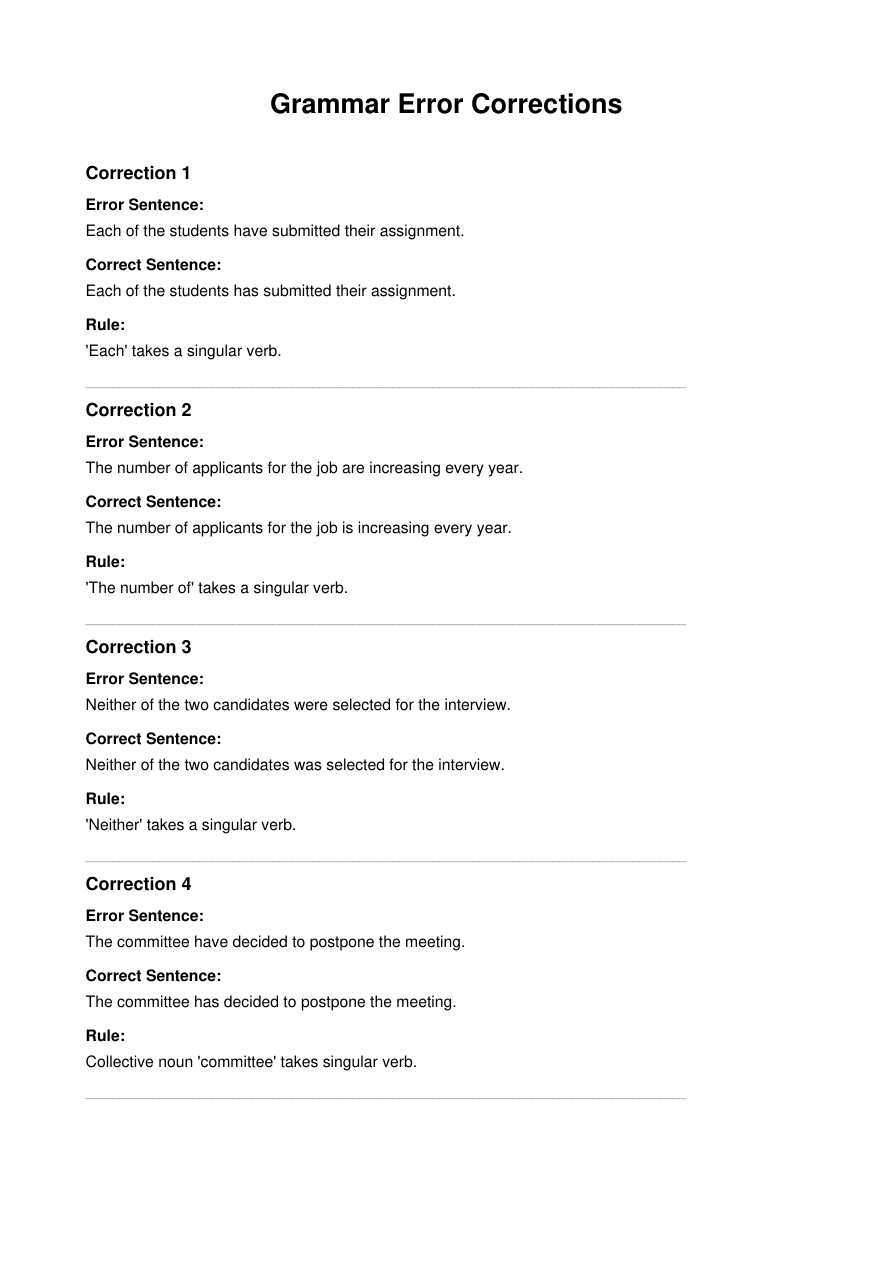

In [29]:
# ============================================================
# 23. OUTPUT PDF PREVIEW
# ============================================================

with fitz.open(
    TEST_OUTPUT_PDF_PATH
) as document:

    first_page = document[0]

    pixmap = first_page.get_pixmap(
        matrix=fitz.Matrix(
            1.5,
            1.5
        ),
        alpha=False
    )

    preview_path = Path(
        "/content/corrections_preview.png"
    )

    pixmap.save(
        str(preview_path)
    )

display(
    Image.open(
        preview_path
    )
)

In [30]:
# ============================================================
# 24. PROCESSING SUMMARY
# ============================================================

def create_processing_summary(
    source_pdf: str,
    pages: list[dict],
    mined_corrections: list[dict],
    valid_corrections: list[dict],
    new_corrections: list[dict],
    duplicate_corrections: list[dict],
    rejected_corrections: list[dict],
    failed_chunks: list[dict]
) -> dict:

    ocr_pages = sum(
        1
        for page in pages
        if page.get(
            "used_ocr",
            False
        )
    )

    if failed_chunks:
        status = "PARTIALLY_COMPLETED"

    elif not valid_corrections:
        status = "NO_VALID_CORRECTIONS"

    else:
        status = "COMPLETED"

    return {
        "source_pdf": source_pdf,
        "pages_processed": len(pages),
        "ocr_pages": ocr_pages,
        "items_detected":
            len(mined_corrections),
        "valid_corrections":
            len(valid_corrections),
        "new_rules":
            len(new_corrections),
        "duplicates_skipped":
            len(duplicate_corrections),
        "rejected_items":
            len(rejected_corrections),
        "failed_chunks":
            len(failed_chunks),
        "status": status,
        "processed_at": datetime.now(
            timezone.utc
        ).isoformat()
    }

In [31]:
# ============================================================
# 25. FORMAT SUMMARY TEXT
# ============================================================

def format_processing_summary(
    summary: dict
) -> str:

    return (
        "PDF Grammar Mining Completed\n\n"
        f"File: {summary['source_pdf']}\n"
        f"Pages processed: {summary['pages_processed']}\n"
        f"OCR pages: {summary['ocr_pages']}\n"
        f"Corrections detected: {summary['items_detected']}\n"
        f"Valid corrections: {summary['valid_corrections']}\n"
        f"New corrections stored: {summary['new_rules']}\n"
        f"Duplicates skipped: {summary['duplicates_skipped']}\n"
        f"Rejected items: {summary['rejected_items']}\n"
        f"Failed chunks: {summary['failed_chunks']}\n\n"
        f"Status: {summary['status']}"
    )

In [32]:
TEST_PROCESSING_SUMMARY = create_processing_summary(
    source_pdf=TEST_PDF_PATH.name,
    pages=TEST_PAGES,
    mined_corrections=TEST_MINED_CORRECTIONS,
    valid_corrections=TEST_VALID_CORRECTIONS,
    new_corrections=TEST_NEW_CORRECTIONS,
    duplicate_corrections=TEST_DUPLICATE_CORRECTIONS,
    rejected_corrections=TEST_REJECTED_CORRECTIONS,
    failed_chunks=TEST_FAILED_CHUNKS
)

TEST_SUMMARY_TEXT = format_processing_summary(
    TEST_PROCESSING_SUMMARY
)

print(TEST_SUMMARY_TEXT)

PDF Grammar Mining Completed

File: error_correction_practice (1).pdf
Pages processed: 7
OCR pages: 0
Corrections detected: 49
Valid corrections: 49
New corrections stored: 49
Duplicates skipped: 0
Rejected items: 0
Failed chunks: 0

Status: COMPLETED


In [33]:
# ============================================================
# 26. SAVE PROCESSING HISTORY
# ============================================================

def save_processing_history(
    summary: dict
) -> pd.DataFrame:

    if HISTORY_CSV.exists():
        history_df = pd.read_csv(
            HISTORY_CSV
        ).fillna("")
    else:
        history_df = pd.DataFrame(
            columns=HISTORY_COLUMNS
        )

    new_row_df = pd.DataFrame(
        [summary]
    )

    all_columns = list(
        dict.fromkeys(
            list(history_df.columns)
            + list(new_row_df.columns)
        )
    )

    history_df = history_df.reindex(
        columns=all_columns
    )

    new_row_df = new_row_df.reindex(
        columns=all_columns
    )

    updated_history = pd.concat(
        [history_df, new_row_df],
        ignore_index=True
    )

    updated_history.to_csv(
        HISTORY_CSV,
        index=False,
        encoding="utf-8"
    )

    print("✅ Processing history saved")
    print(
        "Total processing runs:",
        len(updated_history)
    )

    return updated_history

In [34]:
TEST_HISTORY_DF = save_processing_history(
    TEST_PROCESSING_SUMMARY
)

✅ Processing history saved
Total processing runs: 1


In [35]:
# ============================================================
# 27. COMPLETE PDF PROCESSING PIPELINE
# ============================================================

def process_pdf(
    pdf_path: str | Path
) -> dict:

    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(
            f"PDF not found: {pdf_path}"
        )

    if pdf_path.suffix.lower() != ".pdf":
        raise ValueError(
            "Only PDF files are supported."
        )

    print("=" * 70)
    print("Starting PDF processing")
    print("File:", pdf_path.name)
    print("=" * 70)

    # 1. Extract, OCR and clean
    pages = extract_and_clean_pdf(
        pdf_path
    )

    readable_pages = [
        page
        for page in pages
        if page.get("text", "").strip()
    ]

    if not readable_pages:
        raise ValueError(
            "No readable content was found."
        )

    # 2. Prepare LangChain chunks
    _, chunks = prepare_pdf_chunks(
        pages=pages,
        source_pdf_name=pdf_path.name
    )

    # 3. Mine grammar corrections
    mined_corrections, failed_chunks = (
        mine_grammar_corrections(
            chunks
        )
    )

    # 4. Validate mined records
    valid_corrections, rejected_corrections = (
        validate_mined_results(
            mined_corrections
        )
    )

    # 5. Detect stored duplicates
    existing_rules_df = load_existing_rules()

    (
        new_corrections,
        duplicate_corrections
    ) = separate_new_and_duplicate_rules(
        valid_corrections,
        existing_rules_df
    )

    # 6. Store only new corrections
    saved_df = save_new_corrections(
        records=new_corrections,
        source_pdf=pdf_path.name
    )

    # 7. Generate output PDF containing all valid
    # corrections from the submitted document
    output_pdf_path = None

    if valid_corrections:
        output_pdf_path = create_rules_pdf(
            records=valid_corrections,
            source_pdf_name=pdf_path.name,
            output_directory=OUTPUT_DIR
        )

        verify_generated_pdf(
            output_pdf_path,
            expected_count=len(
                valid_corrections
            )
        )

    # 8. Create summary
    processing_summary = (
        create_processing_summary(
            source_pdf=pdf_path.name,
            pages=pages,
            mined_corrections=mined_corrections,
            valid_corrections=valid_corrections,
            new_corrections=new_corrections,
            duplicate_corrections=duplicate_corrections,
            rejected_corrections=rejected_corrections,
            failed_chunks=failed_chunks
        )
    )

    summary_text = format_processing_summary(
        processing_summary
    )

    # 9. Save processing history
    save_processing_history(
        processing_summary
    )

    print()
    print(summary_text)

    return {
        "summary": processing_summary,
        "summary_text": summary_text,
        "output_pdf_path": (
            str(output_pdf_path)
            if output_pdf_path
            else None
        ),
        "mined_corrections":
            mined_corrections,
        "valid_corrections":
            valid_corrections,
        "new_corrections":
            new_corrections,
        "duplicate_corrections":
            duplicate_corrections,
        "rejected_corrections":
            rejected_corrections,
        "failed_chunks":
            failed_chunks,
        "stored_count":
            len(saved_df)
    }

In [36]:
DUPLICATE_TEST_RESULT = process_pdf(
    TEST_PDF_PATH
)

Starting PDF processing
File: error_correction_practice (1).pdf
Total pages found: 7

✅ Extraction completed
Readable pages: 7
OCR pages: 0
Repeated header/footer lines removed: 0
✅ Small PDF: processing as one complete document
Chunk 1: 9935 characters
Processing chunk 1/1 (9935 characters)
✅ Chunk 1: 49 corrections found

✅ Total mined corrections: 49
Failed chunks: 0
No new corrections to save.
✅ Output PDF generated
Path: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent/output_pdfs/error_correction_practice_1_mined_corrections.pdf
Corrections included: 49
✅ Generated PDF opened successfully
Pages: 13
Error Sentence labels: 49
Correct Sentence labels: 49
Rule labels: 49
✅ All expected corrections verified
✅ Processing history saved
Total processing runs: 2

PDF Grammar Mining Completed

File: error_correction_practice (1).pdf
Pages processed: 7
OCR pages: 0
Corrections detected: 49
Valid corrections: 49
New corrections stored: 0
Duplicates skipped: 49
Rejected items: 0
Failed c

In [37]:
print(
    "Generated PDF:",
    DUPLICATE_TEST_RESULT[
        "output_pdf_path"
    ]
)

print(
    "New records stored:",
    DUPLICATE_TEST_RESULT[
        "stored_count"
    ]
)

print(
    "Duplicates detected:",
    len(
        DUPLICATE_TEST_RESULT[
            "duplicate_corrections"
        ]
    )
)

Generated PDF: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent/output_pdfs/error_correction_practice_1_mined_corrections.pdf
New records stored: 0
Duplicates detected: 49


In [39]:
# ============================================================
# 29. EMAIL CREDENTIALS
# ============================================================

AGENT_GMAIL_ADDRESS = userdata.get(
    "AGENT_GMAIL_ADDRESS"
)

AGENT_GMAIL_APP_PASSWORD = userdata.get(
    "AGENT_GMAIL_APP_PASSWORD"
)

if not AGENT_GMAIL_ADDRESS:
    raise ValueError(
        "AGENT_GMAIL_ADDRESS is missing from Colab Secrets."
    )

if not AGENT_GMAIL_APP_PASSWORD:
    raise ValueError(
        "AGENT_GMAIL_APP_PASSWORD is missing from Colab Secrets."
    )

AGENT_GMAIL_APP_PASSWORD = (
    AGENT_GMAIL_APP_PASSWORD.replace(" ", "")
)

print("✅ Email credentials loaded")
print("Agent email:", AGENT_GMAIL_ADDRESS)

✅ Email credentials loaded
Agent email: vishalchandran6126@gmail.com


In [40]:
# ============================================================
# 30. TEST IMAP CONNECTION
# ============================================================

IMAP_HOST = "imap.gmail.com"
IMAP_PORT = 993


def test_imap_connection() -> None:
    mailbox = imaplib.IMAP4_SSL(
        IMAP_HOST,
        IMAP_PORT
    )

    try:
        mailbox.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        status, mailbox_data = mailbox.select(
            "INBOX",
            readonly=True
        )

        if status != "OK":
            raise RuntimeError(
                "Could not open the Gmail inbox."
            )

        print("✅ Gmail IMAP connected")
        print("Inbox messages:", int(mailbox_data[0]))

    finally:
        try:
            mailbox.logout()
        except Exception:
            pass


test_imap_connection()

✅ Gmail IMAP connected
Inbox messages: 12025


In [41]:
# ============================================================
# 31. TEST SMTP CONNECTION
# ============================================================

SMTP_HOST = "smtp.gmail.com"
SMTP_PORT = 465


def send_test_email(recipient: str) -> None:
    message = EmailMessage()

    message["From"] = AGENT_GMAIL_ADDRESS
    message["To"] = recipient
    message["Subject"] = "Grammar Rule Miner Connection Test"

    message.set_content(
        "The Grammar Rule Miner email connection is working."
    )

    with smtplib.SMTP_SSL(
        SMTP_HOST,
        SMTP_PORT
    ) as smtp:
        smtp.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        smtp.send_message(message)

    print("✅ Test email sent to:", recipient)

In [74]:
# ============================================================
# 32. EMAIL UTILITIES
# ============================================================

def decode_email_header(value: str | None) -> str:
    if not value:
        return ""

    decoded_parts = decode_header(value)
    result = []

    for part, encoding in decoded_parts:
        if isinstance(part, bytes):
            result.append(
                part.decode(
                    encoding or "utf-8",
                    errors="replace"
                )
            )
        else:
            result.append(str(part))

    return "".join(result).strip()


def safe_filename(filename: str) -> str:
    filename = decode_email_header(filename)

    filename = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        filename
    ).strip("_")

    if not filename:
        filename = "incoming_document.pdf"

    return filename


print("✅ Email utility functions ready")

✅ Email utility functions ready


In [75]:
# ============================================================
# 33. EXTRACT EMAIL BODY
# ============================================================

def decode_email_part(part) -> str:
    payload = part.get_payload(decode=True)

    if not payload:
        return ""

    charset = (
        part.get_content_charset()
        or "utf-8"
    )

    try:
        return payload.decode(
            charset,
            errors="replace"
        )
    except Exception:
        return payload.decode(
            "utf-8",
            errors="replace"
        )


def extract_email_body(parsed_email) -> str:
    plain_parts = []
    html_parts = []

    if parsed_email.is_multipart():
        for part in parsed_email.walk():
            content_type = part.get_content_type()

            disposition = str(
                part.get(
                    "Content-Disposition",
                    ""
                )
            ).lower()

            # Ignore file attachments
            if "attachment" in disposition:
                continue

            if content_type == "text/plain":
                plain_parts.append(
                    decode_email_part(part)
                )

            elif content_type == "text/html":
                html_parts.append(
                    decode_email_part(part)
                )

    else:
        content_type = (
            parsed_email.get_content_type()
        )

        if content_type == "text/plain":
            plain_parts.append(
                decode_email_part(parsed_email)
            )

        elif content_type == "text/html":
            html_parts.append(
                decode_email_part(parsed_email)
            )

    if plain_parts:
        return "\n".join(
            plain_parts
        ).strip()

    # Fallback for HTML-only messages
    html_body = "\n".join(html_parts)

    html_body = re.sub(
        r"<style.*?</style>",
        " ",
        html_body,
        flags=re.IGNORECASE | re.DOTALL
    )

    html_body = re.sub(
        r"<script.*?</script>",
        " ",
        html_body,
        flags=re.IGNORECASE | re.DOTALL
    )

    html_body = re.sub(
        r"<[^>]+>",
        " ",
        html_body
    )

    html_body = re.sub(
        r"&nbsp;",
        " ",
        html_body,
        flags=re.IGNORECASE
    )

    html_body = re.sub(
        r"\s+",
        " ",
        html_body
    )

    return html_body.strip()


print("✅ Email-body extractor ready")

✅ Email-body extractor ready


In [85]:
# ============================================================
# 34. FIND UNREAD /agent grammar EMAILS
# ============================================================

IMAP_HOST = "imap.gmail.com"
IMAP_PORT = 993

AGENT_SUBJECT_TRIGGER = "/agent grammar"


def find_unread_agent_emails(
    maximum_results: int = 10
) -> list[str]:

    mailbox = imaplib.IMAP4_SSL(
        IMAP_HOST,
        IMAP_PORT
    )

    try:
        mailbox.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        status, _ = mailbox.select(
            "INBOX",
            readonly=True
        )

        if status != "OK":
            raise RuntimeError(
                "Could not open Gmail inbox."
            )

        mailbox.noop()

        # Search only unread emails whose subject
        # contains the exact trigger phrase.
        search_query = (
            f'(UNSEEN SUBJECT "{AGENT_SUBJECT_TRIGGER}")'
        )

        status, search_data = mailbox.search(
            None,
            search_query
        )

        if status != "OK":
            raise RuntimeError(
                "Agent email search failed."
            )

        message_ids = search_data[0].split()

        # Process oldest matching emails first
        selected_ids = message_ids[
            :maximum_results
        ]

        result = [
            message_id.decode()
            for message_id in selected_ids
        ]

        print(
            "✅ Matching /agent grammar emails:",
            len(result)
        )

        return result

    finally:
        try:
            mailbox.close()
        except Exception:
            pass

        try:
            mailbox.logout()
        except Exception:
            pass

In [77]:
PENDING_EMAIL_IDS = find_unread_emails()

✅ Unread email candidates: 10


In [78]:
# ============================================================
# 35. FETCH EMAIL AND PDF ATTACHMENTS
# ============================================================

def fetch_email_and_pdf_attachments(
    message_id: str
) -> dict:

    mailbox = imaplib.IMAP4_SSL(
        IMAP_HOST,
        IMAP_PORT
    )

    try:
        mailbox.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        status, _ = mailbox.select(
            "INBOX",
            readonly=True
        )

        if status != "OK":
            raise RuntimeError(
                "Could not open Gmail inbox."
            )

        status, message_data = mailbox.fetch(
            message_id,
            "(BODY.PEEK[])"
        )

        if status != "OK":
            raise RuntimeError(
                f"Could not fetch email {message_id}."
            )

        raw_email = None

        for item in message_data:
            if (
                isinstance(item, tuple)
                and isinstance(item[1], bytes)
            ):
                raw_email = item[1]
                break

        if not raw_email:
            raise RuntimeError(
                f"Email content missing for {message_id}."
            )

        parsed_email = email.message_from_bytes(
            raw_email
        )

        sender_name, sender_email = parseaddr(
            parsed_email.get("From", "")
        )

        subject = decode_email_header(
            parsed_email.get("Subject")
        )

        body = extract_email_body(
            parsed_email
        )

        message_id_header = parsed_email.get(
            "Message-ID",
            ""
        )

        references = parsed_email.get(
            "References",
            ""
        )

        pdf_paths = []

        for attachment_index, part in enumerate(
            parsed_email.walk(),
            start=1
        ):
            if (
                part.get_content_maintype()
                == "multipart"
            ):
                continue

            original_filename = part.get_filename()

            if not original_filename:
                continue

            decoded_filename = safe_filename(
                original_filename
            )

            content_type = (
                part.get_content_type()
            )

            is_pdf = (
                content_type == "application/pdf"
                or decoded_filename
                .lower()
                .endswith(".pdf")
            )

            if not is_pdf:
                continue

            file_bytes = part.get_payload(
                decode=True
            )

            if not file_bytes:
                continue

            timestamp = datetime.now().strftime(
                "%Y%m%d_%H%M%S_%f"
            )

            final_filename = (
                f"{timestamp}_"
                f"{attachment_index}_"
                f"{decoded_filename}"
            )

            saved_path = (
                INCOMING_DIR / final_filename
            )

            with open(
                saved_path,
                "wb"
            ) as pdf_file:
                pdf_file.write(file_bytes)

            pdf_paths.append(saved_path)

        return {
            "imap_message_id": message_id,
            "sender_name": sender_name,
            "sender_email": sender_email,
            "subject": subject,
            "body": body,
            "message_id_header": message_id_header,
            "references": references,
            "pdf_paths": pdf_paths
        }

    finally:
        try:
            mailbox.close()
        except Exception:
            pass

        try:
            mailbox.logout()
        except Exception:
            pass


print("✅ Email fetcher ready")

✅ Email fetcher ready


In [79]:
# ============================================================
# 36. SEND EMAIL REPLY WITH GENERATED PDF
# ============================================================

def send_processing_reply(
    recipient: str,
    original_subject: str,
    summary_text: str,
    output_pdf_path: str | Path | None,
    original_message_id: str = "",
    references: str = ""
) -> None:

    reply = EmailMessage()

    reply["From"] = AGENT_GMAIL_ADDRESS
    reply["To"] = recipient

    subject = (
        original_subject.strip()
        or "Grammar PDF Processing"
    )

    if not subject.lower().startswith("re:"):
        subject = f"Re: {subject}"

    reply["Subject"] = subject

    if original_message_id:
        reply["In-Reply-To"] = (
            original_message_id
        )

        reference_values = [
            value.strip()
            for value in [
                references,
                original_message_id
            ]
            if value and value.strip()
        ]

        if reference_values:
            reply["References"] = " ".join(
                reference_values
            )

    reply.set_content(summary_text)

    if output_pdf_path:
        output_pdf_path = Path(
            output_pdf_path
        )

        if not output_pdf_path.exists():
            raise FileNotFoundError(
                f"Output PDF not found: "
                f"{output_pdf_path}"
            )

        with open(
            output_pdf_path,
            "rb"
        ) as pdf_file:
            pdf_data = pdf_file.read()

        reply.add_attachment(
            pdf_data,
            maintype="application",
            subtype="pdf",
            filename=output_pdf_path.name
        )

    with smtplib.SMTP_SSL(
        SMTP_HOST,
        SMTP_PORT
    ) as smtp:
        smtp.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        smtp.send_message(reply)

    print("✅ Reply sent to:", recipient)

In [80]:
# ============================================================
# 37. MARK EMAIL AS READ
# ============================================================

def mark_email_as_read(
    message_id: str
) -> None:

    mailbox = imaplib.IMAP4_SSL(
        IMAP_HOST,
        IMAP_PORT
    )

    try:
        mailbox.login(
            AGENT_GMAIL_ADDRESS,
            AGENT_GMAIL_APP_PASSWORD
        )

        status, _ = mailbox.select(
            "INBOX",
            readonly=False
        )

        if status != "OK":
            raise RuntimeError(
                "Could not open Gmail inbox."
            )

        status, _ = mailbox.store(
            message_id,
            "+FLAGS",
            "\\Seen"
        )

        if status != "OK":
            raise RuntimeError(
                f"Could not mark email "
                f"{message_id} as read."
            )

        print(
            "✅ Email marked as read:",
            message_id
        )

    finally:
        try:
            mailbox.close()
        except Exception:
            pass

        try:
            mailbox.logout()
        except Exception:
            pass

In [93]:
# ============================================================
# 38. PROCESS MATCHED AGENT EMAIL
# ============================================================

def process_email_message(
    message_id: str
) -> list[dict]:

    email_data = fetch_email_and_pdf_attachments(
        message_id
    )

    sender_email = email_data[
        "sender_email"
    ]

    subject = email_data[
        "subject"
    ]

    pdf_paths = email_data[
        "pdf_paths"
    ]

    if not sender_email:
        raise ValueError(
            "Sender email address could not "
            "be identified."
        )

    if not pdf_paths:
        send_processing_reply(
            recipient=sender_email,
            original_subject=subject,
            summary_text=(
                "The /agent grammar command was detected, "
                "but no PDF attachment was found.\n\n"
                "Please attach at least one PDF "
                "and send the email again."
            ),
            output_pdf_path=None,
            original_message_id=email_data[
                "message_id_header"
            ],
            references=email_data[
                "references"
            ]
        )

        mark_email_as_read(message_id)

        return []

    results = []

    for pdf_path in pdf_paths:
        print()
        print("=" * 70)
        print(
            "Processing attachment:",
            pdf_path.name
        )
        print("=" * 70)

        try:
            result = process_pdf(
                pdf_path
            )

            send_processing_reply(
                recipient=sender_email,
                original_subject=subject,
                summary_text=result[
                    "summary_text"
                ],
                output_pdf_path=result[
                    "output_pdf_path"
                ],
                original_message_id=email_data[
                    "message_id_header"
                ],
                references=email_data[
                    "references"
                ]
            )

            results.append({
                "pdf_path": str(pdf_path),
                "status": "COMPLETED",
                "result": result
            })

        except Exception as error:
            failure_text = (
                "PDF Grammar Mining Failed\n\n"
                f"File: {pdf_path.name}\n"
                f"Reason: {str(error)[:1000]}"
            )

            try:
                send_processing_reply(
                    recipient=sender_email,
                    original_subject=subject,
                    summary_text=failure_text,
                    output_pdf_path=None,
                    original_message_id=email_data[
                        "message_id_header"
                    ],
                    references=email_data[
                        "references"
                    ]
                )
            except Exception as reply_error:
                print(
                    "❌ Could not send failure reply:",
                    reply_error
                )

            results.append({
                "pdf_path": str(pdf_path),
                "status": "FAILED",
                "error": str(error)
            })

    mark_email_as_read(
        message_id
    )

    return results

In [90]:
# ============================================================
# 39. RUN EMAIL AGENT ONCE
# ============================================================

def run_email_agent_once(
    maximum_results: int = 10
) -> list[dict]:

    pending_ids = find_unread_agent_emails(
        maximum_results=maximum_results
    )

    if not pending_ids:
        print(
            "No unread /agent grammar emails found."
        )
        return []

    all_results = []

    for message_id in pending_ids:
        try:
            results = process_email_message(
                message_id
            )

            all_results.extend(
                results
            )

        except Exception as error:
            print(
                f"❌ Email {message_id} failed:",
                error
            )

    print()
    print("✅ Email-agent check completed")
    print(
        "Attachments processed:",
        len(all_results)
    )

    return all_results

In [99]:
EMAIL_AGENT_RESULTS = run_email_agent_once(
    maximum_results=10
)

✅ Matching /agent grammar emails: 1

Processing attachment: 20260804_172321_954499_5_CTS_English_Model_Paper.pdf
Starting PDF processing
File: 20260804_172321_954499_5_CTS_English_Model_Paper.pdf
Total pages found: 11

✅ Extraction completed
Readable pages: 11
OCR pages: 0
Repeated header/footer lines removed: 0
✅ Small PDF: processing as one complete document
Chunk 1: 7879 characters
Processing chunk 1/1 (7879 characters)
✅ Chunk 1: 30 corrections found

✅ Total mined corrections: 30
Failed chunks: 0
✅ New corrections saved: 30
✅ Total stored rules: 126
✅ Output PDF generated
Path: /content/drive/MyDrive/Grammar_Rule_Miner_Email_Agent/output_pdfs/20260804_172321_954499_5_CTS_English_Model_Paper_mined_corrections.pdf
Corrections included: 30
✅ Generated PDF opened successfully
Pages: 8
Error Sentence labels: 30
Correct Sentence labels: 30
Rule labels: 30
✅ All expected corrections verified
✅ Processing history saved
Total processing runs: 7

PDF Grammar Mining Completed

File: 20260804